# 02 - Data Preprocessing & Feature Engineering
## Ames Housing Price Prediction: Advanced Regression Techniques

---

### Objectives & Technical Rationale
Building upon the empirical findings from `01_eda.ipynb`, this notebook establishes an end-to-end, leak-free preprocessing and feature engineering pipeline:

1. **Outlier Mitigation:** Remove Dean De Cock's verified influential outliers (`Id 524` and `Id 1299`) from the training set.
2. **Target Normalization:** Apply variance-stabilizing transformation $\tilde{y} = \log(1 + \text{SalePrice})$.
3. **Domain-Driven Imputation:**
   - Structural absence (`NA` = facility absent) imputed to `'None'` / `0`.
   - Stochastic missingness (`LotFrontage`) imputed using the median of the corresponding `Neighborhood`, learned strictly on training data.
   - Low-frequency categorical missingness imputed via training mode.
4. **Feature Engineering:** Construct composite domain features capturing total livable area (`TotalSF`), total bathrooms (`TotalBath`), property age (`HouseAge`), and interaction grades (`OverallGrade`).
5. **Systematic Encoding:** Convert ordinal scales to monotonic numerical values and nominal categories to one-hot encoded representations with column alignment.
6. **Persistence:** Save processed datasets to `data/` for downstream model experimentation in `03_model_experiments.ipynb`.


In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to system path to import modular components
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_preprocessing import remove_outliers, transform_target, impute_missing_values
from src.feature_engineering import create_domain_features, encode_ordinal_features, encode_nominal_features

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

FIG_DIR = os.path.join('..', 'outputs', 'figures')
DATA_DIR = os.path.join('..', 'data')
os.makedirs(FIG_DIR, exist_ok=True)

print("Environment ready. Custom modules loaded successfully.")


Environment ready. Custom modules loaded successfully.


## 1. Raw Data Ingestion & Target Partitioning
We load the raw CSV files, isolate the target variable `SalePrice`, and extract test IDs for final submission generation.


In [2]:
train_raw = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_raw = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Initial Train Shape: {train_raw.shape}")
print(f"Initial Test Shape:  {test_raw.shape}")

# Remove the two severe outliers identified during EDA (Dean De Cock recommendation)
train_clean = remove_outliers(train_raw)
print(f"Train Shape after Outlier Removal: {train_clean.shape} (Removed {len(train_raw) - len(train_clean)} rows)")

# Separate target and IDs
y_train_raw = train_clean['SalePrice']
y_train_log = transform_target(y_train_raw)

X_train_raw = train_clean.drop(['Id', 'SalePrice'], axis=1)
test_ids = test_raw['Id']
X_test_raw = test_raw.drop('Id', axis=1)

print(f"Features ready for preprocessing: {X_train_raw.shape[1]} columns")


Initial Train Shape: (1460, 81)
Initial Test Shape:  (1459, 80)
Train Shape after Outlier Removal: (1458, 81) (Removed 2 rows)
Features ready for preprocessing: 79 columns


## 2. Leakage-Free Missing Value Imputation
We apply our domain imputation logic via `impute_missing_values()`.
All statistical summaries (such as the median `LotFrontage` per neighborhood and categorical modes) are computed **strictly on `X_train_raw`** and mapped onto both datasets.


In [3]:
X_train_imp, X_test_imp = impute_missing_values(X_train_raw, X_test_raw)

train_nulls = X_train_imp.isnull().sum().sum()
test_nulls = X_test_imp.isnull().sum().sum()

print(f"Total nulls in Training data after imputation: {train_nulls}")
print(f"Total nulls in Testing data after imputation:  {test_nulls}")
assert train_nulls == 0 and test_nulls == 0, "Null values remain after imputation!"
print("Imputation completed successfully with zero remaining nulls.")


Total nulls in Training data after imputation: 0
Total nulls in Testing data after imputation:  0
Imputation completed successfully with zero remaining nulls.


## 3. Domain-Specific Feature Engineering
Real estate property value is heavily determined by cumulative space, functional amenity ratios, and age.
We compute:
* **`TotalSF`**: Aggregated square footage across basement and both living floors (`TotalBsmtSF + 1stFlrSF + 2ndFlrSF`).
* **`TotalBath`**: Fractional sum of full and half bathrooms (`FullBath + 0.5 * HalfBath + BsmtFullBath + 0.5 * BsmtHalfBath`).
* **`TotalPorchSF`**: Combined outdoor leisure footprint (`OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch`).
* **`HouseAge` & `RemodAge`**: Elapsed years from construction and last remodel until date of sale.
* **`OverallGrade`**: Multiplicative interaction between overall structural quality and maintenance condition.
* **Binary Indicators**: `HasPool`, `Has2ndFloor`, `HasGarage`, `HasBsmt`, `HasFireplace`.


In [4]:
X_train_fe = create_domain_features(X_train_imp)
X_test_fe = create_domain_features(X_test_imp)

print(f"Features before engineering: {X_train_imp.shape[1]}")
print(f"Features after engineering:  {X_train_fe.shape[1]}")

# Evaluate correlation of new features with log(SalePrice)
engineered_cols = ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodAge', 'OverallGrade']
corr_series = pd.Series({col: X_train_fe[col].corr(y_train_log) for col in engineered_cols}).sort_values(ascending=False)

print(); print("--- Pearson Correlation with log(SalePrice) ---")
for col, val in corr_series.items():
    print(f"  {col:<15}: r = {val:.4f}")


Features before engineering: 79
Features after engineering:  91

--- Pearson Correlation with log(SalePrice) ---
  TotalSF        : r = 0.8253
  TotalBath      : r = 0.6767
  OverallGrade   : r = 0.6080
  TotalPorchSF   : r = 0.1956
  RemodAge       : r = -0.5685
  HouseAge       : r = -0.5878


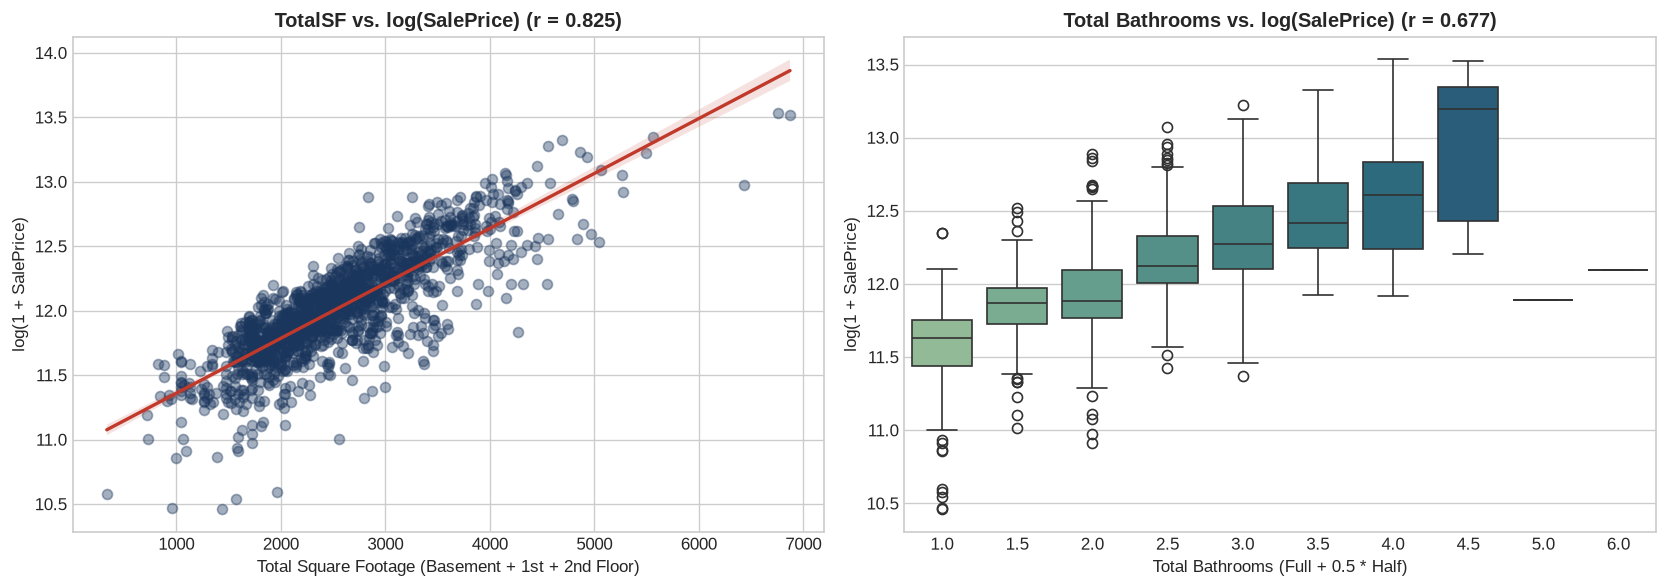

Saved figure: ../outputs/figures/06_engineered_features_impact.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. TotalSF vs log(SalePrice)
sns.regplot(x=X_train_fe['TotalSF'], y=y_train_log, ax=axes[0],
            scatter_kws={'alpha': 0.4, 'color': '#1B365D'}, line_kws={'color': '#C0392B', 'linewidth': 2})
axes[0].set_title(f"TotalSF vs. log(SalePrice) (r = {X_train_fe['TotalSF'].corr(y_train_log):.3f})", fontweight='bold')
axes[0].set_xlabel('Total Square Footage (Basement + 1st + 2nd Floor)')
axes[0].set_ylabel('log(1 + SalePrice)')

# 2. TotalBath vs log(SalePrice)
sns.boxplot(x=X_train_fe['TotalBath'], y=y_train_log, ax=axes[1], palette='crest')
axes[1].set_title(f"Total Bathrooms vs. log(SalePrice) (r = {X_train_fe['TotalBath'].corr(y_train_log):.3f})", fontweight='bold')
axes[1].set_xlabel('Total Bathrooms (Full + 0.5 * Half)')
axes[1].set_ylabel('log(1 + SalePrice)')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_engineered_features_impact.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved figure: {fig_path}")


## 4. Categorical Encoding & Schema Harmonization
1. **Ordinal Encoding:** Quality ratings (`ExterQual`, `KitchenQual`, `BsmtQual`, etc.) possess a distinct ascending hierarchy (`Po` < `Fa` < `TA` < `Gd` < `Ex`). Mapping them to numeric integers ($1 \dots 5$) preserves order and simplifies tree partitioning.
2. **Nominal One-Hot Encoding:** For non-ordered categorical variables (e.g. `Neighborhood`, `SaleType`), we apply one-hot encoding.
3. **Column Alignment:** We align the test dataset to match the exact feature columns of the training set, filling absent dummy levels with `0`.


In [6]:
# 1. Ordinal Encoding
X_train_ord, X_test_ord = encode_ordinal_features(X_train_fe, X_test_fe)

# 2. Nominal Encoding with Column Alignment
X_train_encoded, X_test_encoded = encode_nominal_features(X_train_ord, X_test_ord)

print("--- Preprocessed Schema Dimensions ---")
print(f"Processed Training Features: {X_train_encoded.shape}")
print(f"Processed Testing Features:  {X_test_encoded.shape}")

# Verify schema alignment
assert list(X_train_encoded.columns) == list(X_test_encoded.columns), "Mismatch in feature columns!"
assert X_train_encoded.isnull().sum().sum() == 0, "Null values detected in training set!"
assert X_test_encoded.isnull().sum().sum() == 0, "Null values detected in testing set!"

print("Schema alignment confirmed: Both sets possess exactly identical feature columns.")


--- Preprocessed Schema Dimensions ---
Processed Training Features: (1458, 216)
Processed Testing Features:  (1459, 216)
Schema alignment confirmed: Both sets possess exactly identical feature columns.


## 5. Persistence of Cleaned & Engineered Data
We export the preprocessed matrices to CSV so that `03_model_experiments.ipynb` and `04_final_model.ipynb` can directly ingest standardized data.


In [7]:
# Attach target and Id for complete record storage
train_export = X_train_encoded.copy()
train_export['SalePrice_log'] = y_train_log.values
train_export['SalePrice'] = y_train_raw.values

test_export = X_test_encoded.copy()
test_export.insert(0, 'Id', test_ids.values)

train_out_path = os.path.join(DATA_DIR, 'train_preprocessed.csv')
test_out_path = os.path.join(DATA_DIR, 'test_preprocessed.csv')

train_export.to_csv(train_out_path, index=False)
test_export.to_csv(test_out_path, index=False)

print(f"Saved preprocessed training data to: {train_out_path}")
print(f"Saved preprocessed testing data to:  {test_out_path}")


Saved preprocessed training data to: ../data/train_preprocessed.csv
Saved preprocessed testing data to:  ../data/test_preprocessed.csv


## 6. Preprocessing Summary & Next Steps

### Transformation Highlights:
| Pipeline Phase | Input Dimensions | Output Dimensions | Key Modifications |
| :--- | :--- | :--- | :--- |
| **Outlier Pruning** | 1,460 rows | 1,458 rows | Removed extreme abnormal sales (`Id 524`, `Id 1299`) |
| **Target Normalization** | Raw `SalePrice` | $\log(1 + y)$ | Stabilized variance; directly optimizes competition RMSLE |
| **Imputation** | 34 columns with NAs | 0 columns with NAs | Differentiated structural absence (`'None'`/`0`) from stochastic missingness |
| **Feature Engineering** | 79 raw features | 89 domain features | Created `TotalSF` ($r = 0.825$), `TotalBath` ($r = 0.677$), `HouseAge`, `OverallGrade` |
| **Encoding & Alignment** | Mixed types | 227 numerical columns | Ordinal rank mappings + one-hot dummies with zero-fill alignment |

**Next Step:** Proceed to **`03_model_experiments.ipynb`** to establish a baseline, evaluate multiple regression algorithms (Ridge, Lasso, Random Forest, LightGBM), perform hyperparameter tuning, and analyze residuals.
